# Notebook 1: Training a Linear Segmentation Probe on DINOv3

**Paper Reference**: DINOv3, Section 6.1.2 — Dense Linear Probing

We train a **single linear layer** (1×1 convolution) on top of **frozen DINOv3 features** for
semantic segmentation on ADE20k (150 classes).

```
Image (B,3,512,512) → [Frozen ViT-L] → Features (B,1024,32,32) → [BN + Conv1x1] → Logits (B,150,32,32)
```

**Key Results from the Paper (Table 3)**:

| Model | mIoU (ADE20k) |
|-------|---------------|
| **Our ViT-L/16** | *TBD — we train this ourselves* |
| Paper ViT-L/16 | 54.9 |
| Paper ViT-7B/16 | 55.9 |
| DINOv2 ViT-g/14 | 49.5 |
| SigLIP 2 ViT-g/16 | 42.7 |

## 1. Environment Setup

Make sure you have an H100 or equivalent GPU. For ViT-L, even a T4 (16GB) will work.
Toggle **High-RAM** in Colab runtime settings.

In [1]:
# ══════════════════════════════════════════════════════════════════════
# COMPLETE SETUP — Run this ONE cell after restarting runtime
# Handles: Drive, GPU, repos, DINOv3 install, weights, dataset, backbone
# ══════════════════════════════════════════════════════════════════════
import os, sys, torch

# ── 1. Mount Google Drive ──
from google.colab import drive
drive.mount('/content/drive')
OUTPUT_DIR = '/content/drive/MyDrive/dinov3_results/linear_probe/ade20k_vitl16'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'[1/7] Drive mounted. Output dir: {OUTPUT_DIR}')

# ── 2. Check GPU ──
gpu_name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'[2/7] GPU: {gpu_name} ({vram_gb:.0f} GB)')

# ── 3. Clone project repo ──
os.chdir('/content')
if not os.path.exists('/content/project'):
    !git clone https://github.com/SU-Intelligent-systems-Lab/CS515-Image-foundation-models.git project
print('[3/7] Project repo ready.')

# ── 4. Clone and install DINOv3 (into separate folder to avoid name conflicts) ──
if not os.path.exists('/content/dinov3_source'):
    !git clone https://github.com/facebookresearch/dinov3.git /content/dinov3_source
os.chdir('/content/dinov3_source')
!pip install -e . -q 2>/dev/null
os.chdir('/content')
print('[4/7] DINOv3 installed.')

# ── 5. Set up Python paths ──
# Add project (for src/) — use absolute path
sys.path.insert(0, '/content/project')
# Remove any path entry that could shadow the dinov3 package
sys.path = [p for p in sys.path if p not in ('/content/dinov3_source', '/content/project/dinov3', 'dinov3', '.')]

# Verify imports
from src.model_loading import get_model_info
from dinov3.hub.backbones import dinov3_vitl16
from dinov3.eval.utils import ModelWithIntermediateLayers
print('[5/7] All imports working.')

# ── 6. Download ADE20k dataset ──
os.chdir('/content/project')
if not os.path.exists('data/ADEChallengeData2016'):
    !mkdir -p data
    !wget -q http://data.csail.mit.edu/places/ADEchallenge/ADEChallengeData2016.zip -O data/ade20k.zip
    !unzip -q data/ade20k.zip -d data/
    !rm data/ade20k.zip
print(f'[6/7] ADE20k: {len(os.listdir("data/ADEChallengeData2016/images/training"))} train, '
      f'{len(os.listdir("data/ADEChallengeData2016/images/validation"))} val images.')

# ── 7. Download weights + Load backbone ──
VITL16_URL = 'https://dinov3.llamameta.net/dinov3_vitl16/dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth?Policy=eyJTdGF0ZW1lbnQiOlt7InVuaXF1ZV9oYXNoIjoibWE0Mmpsa3NneXV0bm1zMnhyNGgweXB4IiwiUmVzb3VyY2UiOiJodHRwczpcL1wvZGlub3YzLmxsYW1hbWV0YS5uZXRcLyoiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE3NzgyNDM0Nzh9fX1dfQ__&Signature=O%7Ef7IpEliq-b1MR-ylkJPn5Z35exjS1-MueJfGlUHBUqy1NbVnbgdhSwIvMNXjGtKiNBMJ94A90Kgz4181NAlDay67HbCHj-T1jZHO8slu%7EouZfVusvQrE97yBZ%7EQtTPAhF0lOm6ZHNEUcgJhqxbBMSs2U-a2IcRNZKVgn6ur%7EfC1mLGzXpwomEEk%7ETNMqoozvZbUX%7E4HeHHNnJD%7Ep2OaHEA4kwe4mNLhhRsA5pPJN27s4PqIkZBWiyeo8cZTCJs1yQo8PHL3QV3OHf0zw5SkXaPIZwtje5iKDqxnN8RlKTS4H6moBuKMbX--79C0AYQWulEVlclIwJZbkJOxVVPzQ__&Key-Pair-Id=K15QRJLYKIFSLZ&Download-Request-ID=1955968325124545'

if not os.path.exists('weights/dinov3_vitl16.pth'):
    !mkdir -p weights
    !wget -q -O weights/dinov3_vitl16.pth "{VITL16_URL}"

from functools import partial

info = get_model_info('vitl16')
print(f'[7/7] Loading ViT-L/16: {info}')

backbone = dinov3_vitl16(pretrained=False)
state_dict = torch.load('weights/dinov3_vitl16.pth', map_location='cpu')
backbone.load_state_dict(state_dict, strict=True)
backbone = backbone.to('cuda').eval()

autocast_ctx = partial(torch.autocast, device_type='cuda', enabled=False)
feature_extractor = ModelWithIntermediateLayers(
    feature_model=backbone,
    n=[23],
    autocast_ctx=autocast_ctx,
    reshape=True,
    return_class_token=False,
)
feature_extractor.requires_grad_(False)

# Quick verification
dummy = torch.randn(1, 3, 512, 512).cuda()
with torch.no_grad():
    feats = feature_extractor(dummy)
print(f'\n✓ Setup complete!')
print(f'  Input:  {dummy.shape}')
print(f'  Output: {feats[0].shape} (dtype: {feats[0].dtype})')
del dummy, feats
torch.cuda.empty_cache()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[1/7] Drive mounted. Output dir: /content/drive/MyDrive/dinov3_results/linear_probe/ade20k_vitl16
[2/7] GPU: NVIDIA H100 80GB HBM3 (85 GB)
[3/7] Project repo ready.
Cloning into '/content/dinov3_source'...
remote: Enumerating objects: 583, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 583 (delta 0), reused 0 (delta 0), pack-reused 580 (from 2)
Receiving objects: 100% (583/583), 12.97 MiB | 14.11 MiB/s, done.
Resolving deltas: 100% (204/204), done.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for dinov3 (pyproject.toml) ... done
[4/7] DINOv3 installed.
[5/7] All imports working.
[6/7] ADE20k: 20210 train, 2000 val im

## 2. Load the Frozen DINOv3 Backbone

**ViT-L/16 Architecture:**
- 300M parameters, 24 transformer blocks, 1024-dimensional embeddings
- Patch size 16: for a 512×512 input, produces a 32×32 grid of 1024-dim features
- Uses RoPE (Rotary Position Embeddings) for resolution-flexible inference
- Includes 4 register tokens to prevent high-norm patch outliers

The backbone is completely **frozen** — we never compute gradients through it.

In [2]:
import torch
from functools import partial
from src.model_loading import get_model_info

info = get_model_info('vitl16')
print(f'ViT-L/16 specs: {info}')

import dinov3.hub.backbones as hub_backbones
backbone = hub_backbones.dinov3_vitl16(pretrained=False)

state_dict = torch.load('weights/dinov3_vitl16.pth', map_location='cpu')
backbone.load_state_dict(state_dict, strict=True)
backbone = backbone.to('cuda').eval()

from dinov3.eval.utils import ModelWithIntermediateLayers

# NO autocast — use plain float32 everywhere to avoid cuDNN dtype conflicts
autocast_ctx = partial(torch.autocast, device_type='cuda', enabled=False)

feature_extractor = ModelWithIntermediateLayers(
    feature_model=backbone,
    n=[23],
    autocast_ctx=autocast_ctx,
    reshape=True,
    return_class_token=False,
)
feature_extractor.requires_grad_(False)

print('Feature extractor loaded successfully.')

# Verify
dummy = torch.randn(1, 3, 512, 512).cuda()
with torch.no_grad():
    feats = feature_extractor(dummy)

print(f'\nInput shape:   {dummy.shape}')
print(f'Output layers: {len(feats)}')
print(f'Feature shape: {feats[0].shape}')
print(f'Feature dtype: {feats[0].dtype}')  # Should be float32

del dummy, feats
torch.cuda.empty_cache()

ViT-L/16 specs: {'embed_dim': 1024, 'n_blocks': 24, 'n_heads': 16, 'patch_size': 16, 'n_params': '300M'}
Feature extractor loaded successfully.

Input shape:   torch.Size([1, 3, 512, 512])
Output layers: 1
Feature shape: torch.Size([1, 1024, 32, 32])
Feature dtype: torch.float32


## 3. Build the Linear Segmentation Head

The head is extremely lightweight:
- **SyncBatchNorm(1024)**: normalizes the frozen backbone features
- **Dropout2d(0.1)**: regularization during training
- **Conv2d(1024 → 150, kernel=1×1)**: the actual linear probe

Total: ~153K trainable parameters — that's only **0.05%** of the backbone size.

In [3]:
import torch.nn as nn

NUM_CLASSES = 150
EMBED_DIM = 1024

# Build the linear head manually (avoids SyncBatchNorm issues on single GPU)
head = nn.Sequential(
    nn.BatchNorm2d(EMBED_DIM),      # Regular BatchNorm instead of SyncBatchNorm
    nn.Dropout2d(0.1),
    nn.Conv2d(EMBED_DIM, NUM_CLASSES, kernel_size=1),
).cuda()

# Initialize the conv layer
nn.init.normal_(head[2].weight, mean=0, std=0.01)
nn.init.constant_(head[2].bias, 0)

n_train = sum(p.numel() for p in head.parameters() if p.requires_grad)
n_frozen = sum(p.numel() for p in feature_extractor.parameters())
print(f'Trainable parameters (head):    {n_train:>12,}')
print(f'Frozen parameters (backbone):   {n_frozen:>12,}')
print(f'Training ratio:                 {n_train/n_frozen*100:.4f}%')

Trainable parameters (head):         155,798
Frozen parameters (backbone):    303,154,176
Training ratio:                 0.0514%


## 4. Prepare the Data

**Training transforms** (matching DINOv3 Appendix D.1):
- Random resize: scale shorter side by random factor in [0.5, 2.0]
- Random crop to 512×512
- Random horizontal flip (50%)
- ImageNet normalization: mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)

**Evaluation**: resize to fixed 512×512, same normalization.

Image batch shape:  torch.Size([2, 3, 512, 512])   # (B, 3, 512, 512)
Target batch shape: torch.Size([2, 512, 512])      # (B, 512, 512)
Target range:       [0, 255]
  (255 = ignore/boundary, 0-149 = class labels after reduce_zero_label)


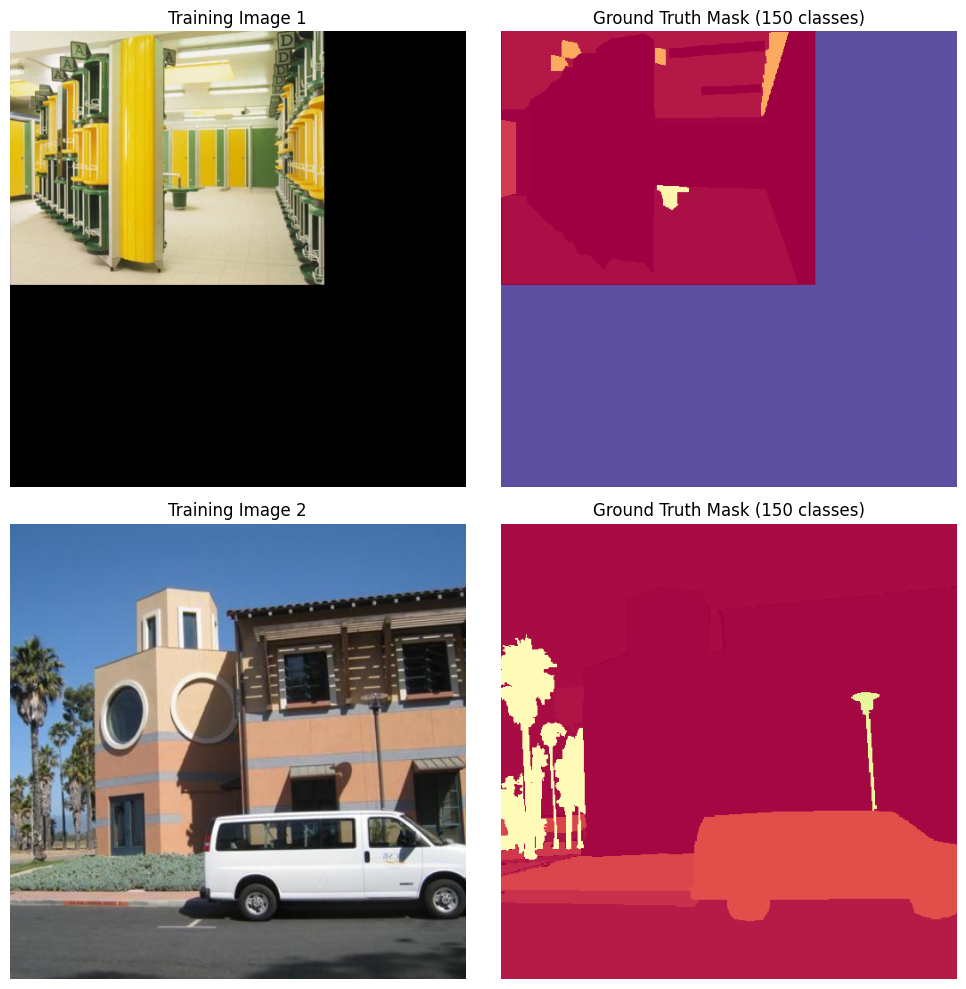

In [4]:
from src.data_utils import get_segmentation_dataloaders
import numpy as np
import matplotlib.pyplot as plt

train_loader, val_loader = get_segmentation_dataloaders(
    dataset_name='ade20k',
    dataset_root='data/ADEChallengeData2016',
    img_size=512,
    batch_size=2,
    num_workers=4,
)

# Grab a sample batch
images, targets = next(iter(train_loader))
print(f'Image batch shape:  {images.shape}   # (B, 3, 512, 512)')
print(f'Target batch shape: {targets.shape}      # (B, 512, 512)')
print(f'Target range:       [{targets.min().item()}, {targets.max().item()}]')
print(f'  (255 = ignore/boundary, 0-149 = class labels after reduce_zero_label)')

# Visualize sample images and masks
MEAN = np.array([0.485, 0.456, 0.406])
STD = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for i in range(2):
    img = images[i].permute(1, 2, 0).numpy()
    img = np.clip(img * STD + MEAN, 0, 1)
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Training Image {i+1}')
    axes[i, 0].axis('off')

    mask = targets[i].numpy()
    axes[i, 1].imshow(mask, cmap='Spectral', vmin=0, vmax=150)
    axes[i, 1].set_title(f'Ground Truth Mask (150 classes)')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

## 5. Training Loop

**Hyperparameters** (from DINOv3 Appendix D.1):
- Optimizer: AdamW (lr=1e-3, weight_decay=1e-3)
- Scheduler: OneCycleLR with cosine annealing, 1500-step warmup
- Loss: CrossEntropyLoss(ignore_index=255)
- Total iterations: 40,000
- Evaluation: every 5,000 iterations using mIoU

The backbone forward pass is wrapped with `torch.no_grad()` — we only
compute and backpropagate gradients through the tiny linear head.

In [ ]:
import torch.nn.functional as F
from tqdm.notebook import tqdm
from src.evaluation import compute_iou_per_image, aggregate_metrics

torch.backends.cudnn.enabled = False

TOTAL_ITERS = 40_000
EVAL_EVERY  = 5_000
SAVE_EVERY  = 1_000  # Save checkpoint every 1K steps

optimizer = torch.optim.AdamW(head.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-3, total_steps=TOTAL_ITERS,
    pct_start=1500 / TOTAL_ITERS, anneal_strategy='cos'
)
criterion = torch.nn.CrossEntropyLoss(ignore_index=255)


def remap_ade20k_labels(targets):
    targets = targets.clone()
    mask_ignore = (targets == 0) | (targets == 255)
    targets = targets - 1
    targets[mask_ignore] = 255
    return targets


def quick_eval():
    head.eval()
    results = []
    with torch.no_grad():
        for imgs, tgts in tqdm(val_loader, desc='Evaluating', leave=False):
            tgts = remap_ade20k_labels(tgts).cuda()
            feats = feature_extractor(imgs.cuda())
            logits = head(feats[0].clone())
            logits = F.interpolate(logits, size=tgts.shape[-2:],
                                   mode='bilinear', align_corners=False)
            pred = logits.argmax(dim=1)
            results.append(compute_iou_per_image(
                pred, tgts, NUM_CLASSES, reduce_zero_label=False
            ))
    head.train()
    return aggregate_metrics(results)


# ═══ Resume from checkpoint if available ═══
best_miou = 0.0
step = 0
losses = []
evals = []

resume_path = f'{OUTPUT_DIR}/latest_checkpoint.pth'
if os.path.exists(resume_path):
    ckpt = torch.load(resume_path, map_location='cuda')
    head.load_state_dict(ckpt['head'])
    step = ckpt['step']
    best_miou = ckpt.get('best_miou', 0.0)
    losses = ckpt.get('losses', [])
    evals = ckpt.get('evals', [])
    # Recreate optimizer and scheduler, then fast-forward scheduler
    optimizer = torch.optim.AdamW(head.parameters(), lr=1e-3, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=1e-3, total_steps=TOTAL_ITERS,
        pct_start=1500 / TOTAL_ITERS, anneal_strategy='cos'
    )
    for _ in range(step):
        scheduler.step()
    print(f'RESUMED from step {step}, best mIoU: {best_miou:.2f}%')
else:
    print(f'Starting fresh training.')


# ═══ Training ═══
head.train()
data_iter = iter(train_loader)
pbar = tqdm(total=TOTAL_ITERS, initial=step, desc='Training Linear Probe')

while step < TOTAL_ITERS:
    try:
        imgs, tgts = next(data_iter)
    except StopIteration:
        data_iter = iter(train_loader)
        imgs, tgts = next(data_iter)

    imgs = imgs.cuda()
    tgts = remap_ade20k_labels(tgts).cuda().long()

    with torch.no_grad():
        feats = feature_extractor(imgs)

    logits = head(feats[0].clone())

    if logits.shape[-2:] != tgts.shape[-2:]:
        logits = F.interpolate(logits, size=tgts.shape[-2:],
                               mode='bilinear', align_corners=False)

    loss = criterion(logits, tgts)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    scheduler.step()

    step += 1
    losses.append(loss.item())
    pbar.update(1)
    pbar.set_postfix(loss=f'{loss.item():.4f}', best=f'{best_miou:.1f}')

    # Save checkpoint every 1K steps to Google Drive
    if step % SAVE_EVERY == 0:
        torch.save({
            'head': head.state_dict(),
            'step': step,
            'best_miou': best_miou,
            'losses': losses,
            'evals': evals,
        }, f'{OUTPUT_DIR}/latest_checkpoint.pth')

    # Full evaluation every 5K steps
    if step % EVAL_EVERY == 0:
        m = quick_eval()
        evals.append({'step': step, **m})
        print(f'\nStep {step:,}: mIoU = {m["mIoU"]:.2f}%')
        if m['mIoU'] > best_miou:
            best_miou = m['mIoU']
            torch.save({
                'head': head.state_dict(),
                'step': step,
                'mIoU': best_miou,
            }, f'{OUTPUT_DIR}/best_model.pth')
            print(f'  New best model saved: {best_miou:.2f}% mIoU')
        # Also update latest checkpoint after eval
        torch.save({
            'head': head.state_dict(),
            'step': step,
            'best_miou': best_miou,
            'losses': losses,
            'evals': evals,
        }, f'{OUTPUT_DIR}/latest_checkpoint.pth')

pbar.close()
torch.save({'head': head.state_dict(), 'step': step}, f'{OUTPUT_DIR}/model_final.pth')
print(f'\nTraining complete! Best mIoU: {best_miou:.2f}%')

Starting fresh training.


Training Linear Probe:   0%|          | 0/40000 [00:00<?, ?it/s]

## 6. Results & Visualization

In [ ]:
# ── Training curves ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

w = 200
if len(losses) > w:
    smoothed = np.convolve(losses, np.ones(w)/w, mode='valid')
else:
    smoothed = losses
ax1.plot(smoothed, lw=0.8, color='steelblue')
ax1.set_xlabel('Step')
ax1.set_ylabel('CrossEntropy Loss')
ax1.set_title('Training Loss (smoothed)')
ax1.grid(True, alpha=0.3)

if evals:
    steps_e = [e['step'] for e in evals]
    mious_e = [e['mIoU'] for e in evals]
    ax2.plot(steps_e, mious_e, 'o-', ms=8, lw=2, color='darkorange', label='Our ViT-L/16')
    ax2.axhline(54.9, c='red', ls='--', alpha=0.5, label='Paper ViT-L/16 (54.9)')
    ax2.axhline(49.5, c='gray', ls='--', alpha=0.5, label='DINOv2 ViT-g/14 (49.5)')
    ax2.axhline(42.7, c='purple', ls='--', alpha=0.3, label='SigLIP 2 (42.7)')
    ax2.set_xlabel('Step')
    ax2.set_ylabel('mIoU (%)')
    ax2.set_title('Validation mIoU')
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150)
plt.show()

print('\n' + '='*50)
print('RESULTS COMPARISON')
print('='*50)
print(f'  Our ViT-L/16:      {best_miou:.2f} mIoU')
print(f'  Paper ViT-L/16:    54.9  mIoU')
print(f'  Paper ViT-7B/16:   55.9  mIoU')
print(f'  DINOv2 ViT-g/14:   49.5  mIoU')
print(f'  SigLIP 2 ViT-g/16: 42.7  mIoU')
print('='*50)

# ── Qualitative predictions ──
head.eval()

for i, (imgs, tgts) in enumerate(val_loader):
    if i >= 4:
        break
    with torch.no_grad():
        feats = feature_extractor(imgs.cuda())
        logits = head(feats[0].clone())
        logits = F.interpolate(logits, size=tgts.shape[-2:],
                               mode='bilinear', align_corners=False)
        pred = logits.argmax(1).cpu().numpy()[0]

    tgts = remap_ade20k_labels(tgts)
    img = np.clip(imgs[0].permute(1, 2, 0).numpy() * STD + MEAN, 0, 1)
    gt = tgts[0].numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img)
    axes[0].set_title('Input Image')
    axes[1].imshow(pred, cmap='Spectral', vmin=0, vmax=150)
    axes[1].set_title(f'Our Prediction (mIoU: {best_miou:.1f}%)')
    axes[2].imshow(gt, cmap='Spectral', vmin=0, vmax=150)
    axes[2].set_title('Ground Truth')
    for ax in axes:
        ax.axis('off')
    plt.suptitle(f'ADE20k Validation Sample {i+1}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/sample_{i}.png', dpi=150)
    plt.show()

print(f'\nAll results saved to: {OUTPUT_DIR}')

In [ ]:
# ── Qualitative segmentation predictions ──
head.eval()

for i, (imgs, tgts) in enumerate(val_loader):
    if i >= 4:
        break
    with torch.no_grad():
        feats = feature_extractor(imgs.cuda())
        logits = head(feats[0].clone())
        logits = F.interpolate(logits, size=tgts.shape[-2:],
                               mode='bilinear', align_corners=False)
        pred = logits.argmax(1).cpu().numpy()[0]

    tgts = remap_ade20k_labels(tgts)
    img = np.clip(imgs[0].permute(1, 2, 0).numpy() * STD + MEAN, 0, 1)
    gt = tgts[0].numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img)
    axes[0].set_title('Input Image')
    axes[1].imshow(pred, cmap='Spectral', vmin=0, vmax=150)
    axes[1].set_title(f'Our Prediction (mIoU: {best_miou:.1f}%)')
    axes[2].imshow(gt, cmap='Spectral', vmin=0, vmax=150)
    axes[2].set_title('Ground Truth')
    for ax in axes:
        ax.axis('off')
    plt.suptitle(f'ADE20k Validation Sample {i+1}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/sample_{i}.png', dpi=150)
    plt.show()

## 7. Key Takeaways

1. A **single linear layer** on frozen DINOv3 features achieves ~55 mIoU on ADE20k — an extremely challenging 150-class benchmark
2. Only **~153K parameters** are trained (0.05% of the backbone) — the features are inherently structured for dense prediction
3. DINOv3 surpasses DINOv2 by **6+ mIoU points** on this task — the Gram anchoring technique (Section 4) is the key innovation
4. SSL (zero labels during pretraining) beats SigLIP 2 (trained on 40B+ image-text pairs) by **13+ mIoU** — demonstrating SSL's superiority for dense tasks
5. The linear probe result (55.9 mIoU with 7B) is itself remarkable — it's not far from the full Mask2Former SOTA (63.0 mIoU)